In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [2]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_counts_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

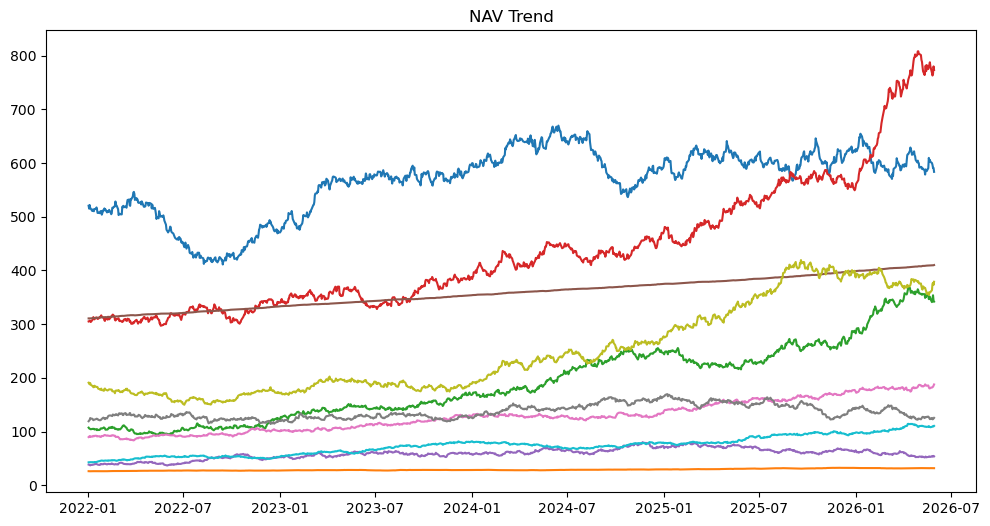

In [ ]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

plt.figure(figsize=(12,6))

for code in nav_history["amfi_code"].unique()[:10]:
    data = nav_history[
        nav_history["amfi_code"] == code
    ]
    plt.plot(
        data["date"],
        data["nav"]
    )

plt.title("NAV Trend")
plt.savefig(
    "../reports/sip_trend.png",
    bbox_inches="tight"
)
plt.show()

Most schemes show a steady increase in NAV over time, indicating long-term growth.

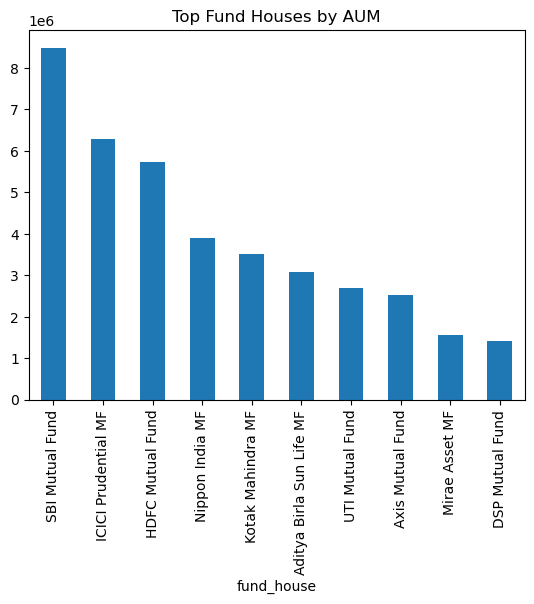

In [ ]:
top_aum = (
    aum.groupby("fund_house")
    ["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_aum.plot(
    kind="bar"
)

plt.title(
    "Top Fund Houses by AUM"
)
plt.savefig("../reports/top_fund_houses_aum.png", bbox_inches="tight")

plt.show()

A few large fund houses account for a major share of the industry's AUM.

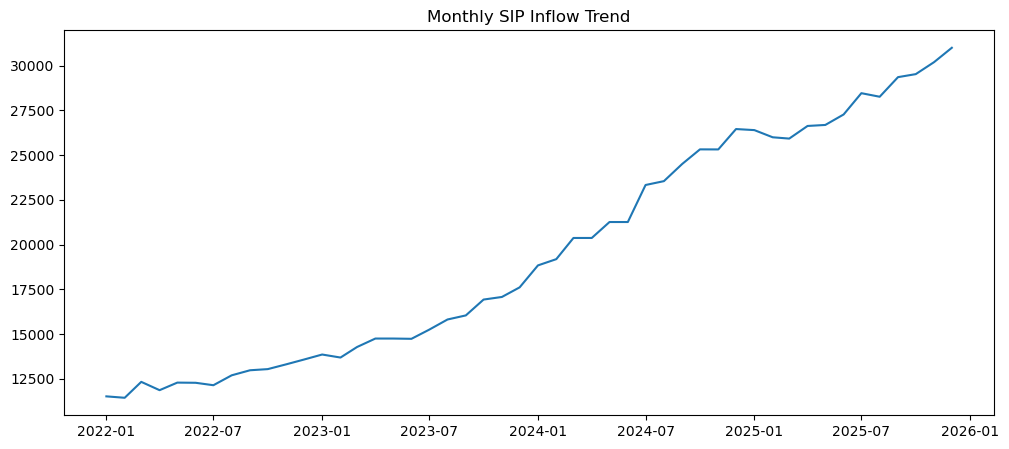

In [ ]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title(
    "Monthly SIP Inflow Trend"
)
plt.savefig("../reports/sip_trend.png", bbox_inches="tight")
plt.show()

SIP inflows have increased consistently, reflecting growing investor participation.

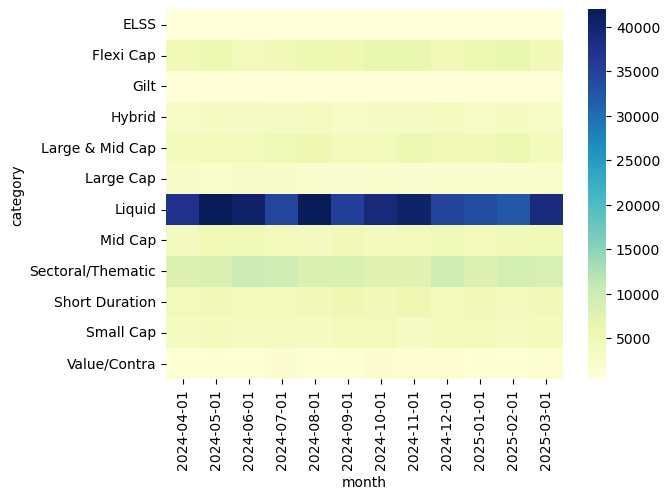

In [ ]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)
plt.savefig("../reports/category_inflow_heatmap.png", bbox_inches="tight")
plt.show()

Certain fund categories attract significantly higher inflows than others.

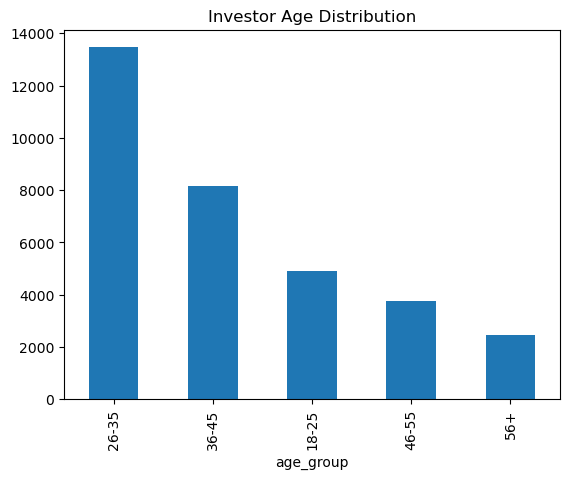

In [ ]:
transactions["age_group"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Investor Age Distribution"
)
plt.savefig("../reports/investor_age_distribution.png", bbox_inches="tight")
plt.show()

Investors from middle-age groups form the largest share of mutual fund investors.

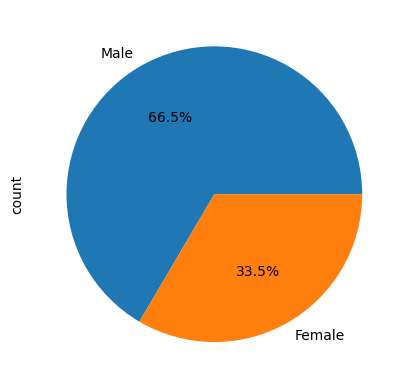

In [ ]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.savefig("../reports/gender_distribution.png", bbox_inches="tight")
plt.show()

The investor base shows a noticeable difference in participation across genders.

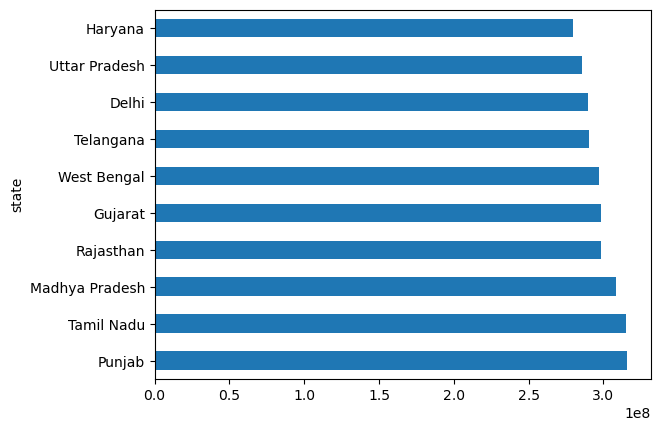

In [ ]:
state_data = (
    transactions.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_data.plot(
    kind="barh"
)
plt.savefig("../reports/state_wise_investment.png", bbox_inches="tight")
plt.show()

Investments are concentrated in a few key states with higher financial activity.

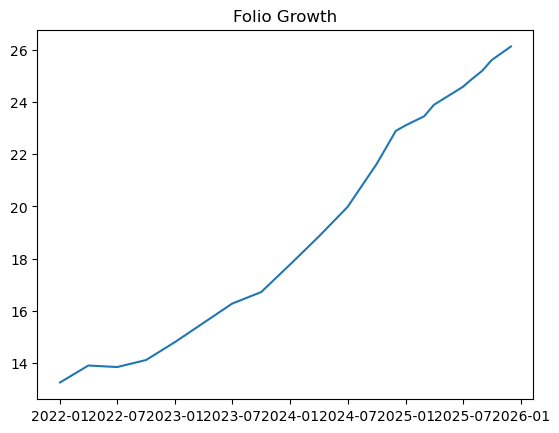

In [ ]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title(
    "Folio Growth"
)
plt.savefig("../reports/folio_growth.png", bbox_inches="tight")

plt.show()

Folio counts increased steadily, indicating expanding mutual fund adoption.

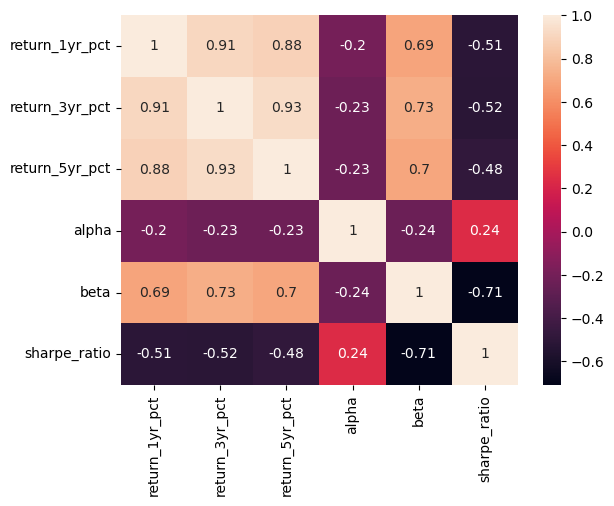

In [ ]:
corr = performance[
[
"return_1yr_pct",
"return_3yr_pct",
"return_5yr_pct",
"alpha",
"beta",
"sharpe_ratio"
]
].corr()

sns.heatmap(
    corr,
    annot=True
)
plt.savefig("../reports/correlation_matrix.png", bbox_inches="tight")
plt.show()

Return-related metrics show strong positive correlations with each other.

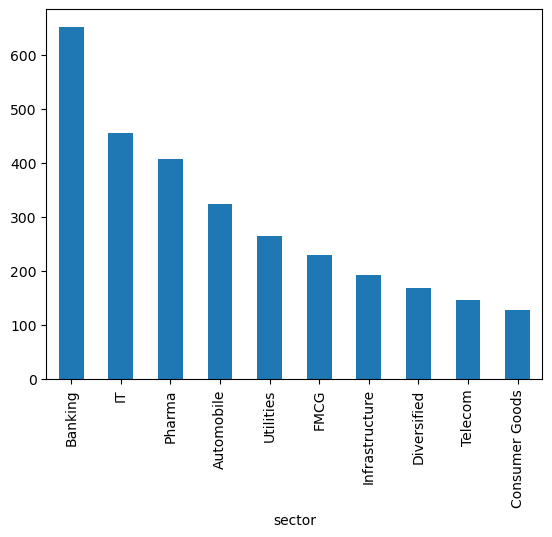

In [ ]:
sector = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

sector.plot(
    kind="bar"
)
plt.savefig("../reports/sector_allocation.png", bbox_inches="tight")
plt.show()

Portfolio investments are concentrated in a few dominant sectors.

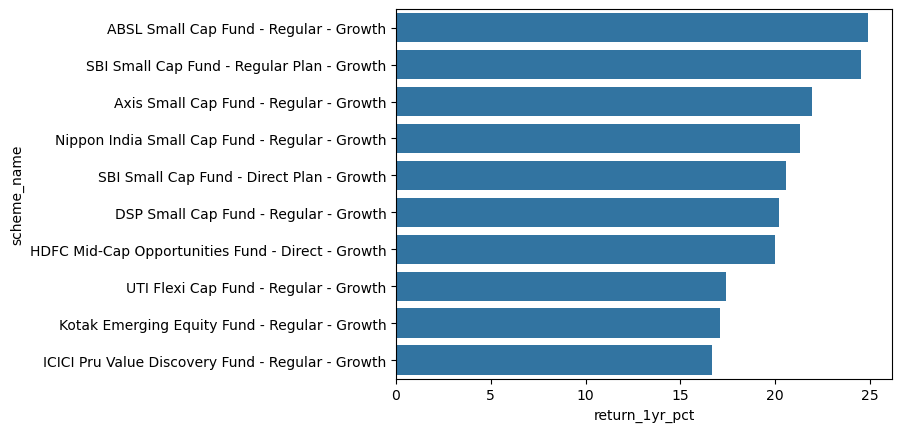

In [ ]:
top_returns = performance.nlargest(
    10,
    "return_1yr_pct"
)

sns.barplot(
    data=top_returns,
    x="return_1yr_pct",
    y="scheme_name"
)
plt.savefig("../reports/top10_funds_return.png", bbox_inches="tight")
plt.show()

Top-performing funds generated significantly higher returns than peers.

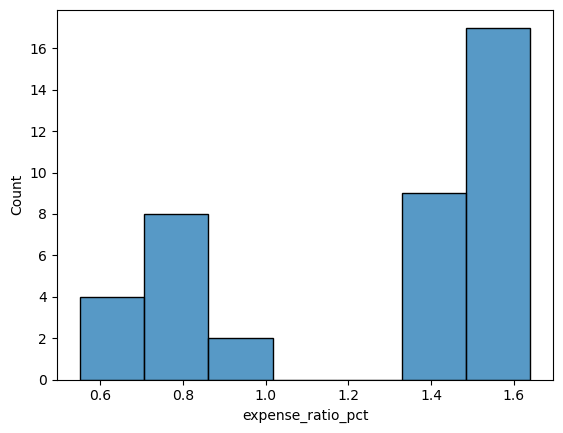

In [ ]:
sns.histplot(
    performance["expense_ratio_pct"]
)
plt.savefig("../reports/expense_ratio_distribution.png", bbox_inches="tight")
plt.show()

Most schemes maintain expense ratios within a moderate range.

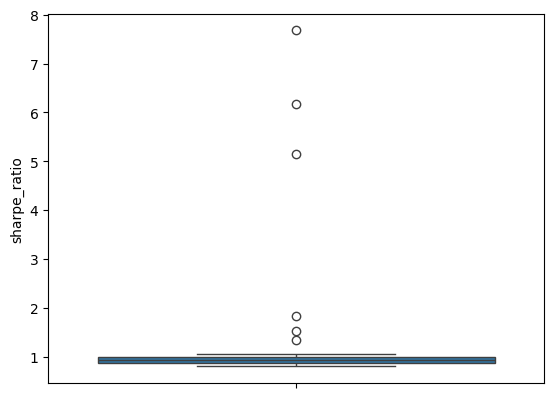

In [ ]:
sns.boxplot(
    performance["sharpe_ratio"]
)
plt.savefig("../reports/sharpe_ratio_distribution.png", bbox_inches="tight")
plt.show()

The majority of funds offer reasonable risk-adjusted returns.

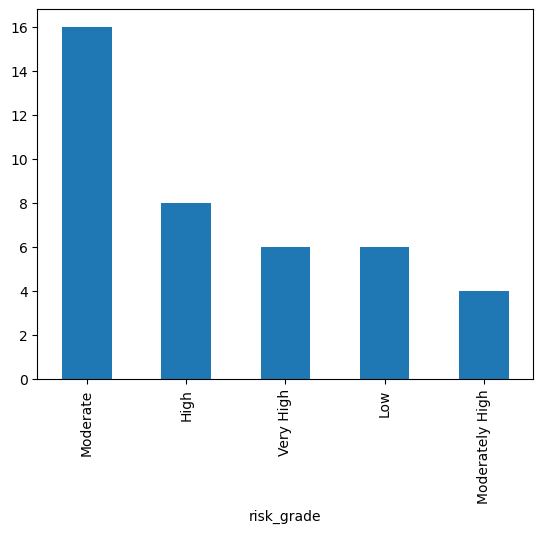

In [ ]:
performance["risk_grade"].value_counts().plot(
    kind="bar"
)
plt.savefig("../reports/risk_grade_distribution.png", bbox_inches="tight")
plt.show()

Most schemes fall into medium to high-risk categories.

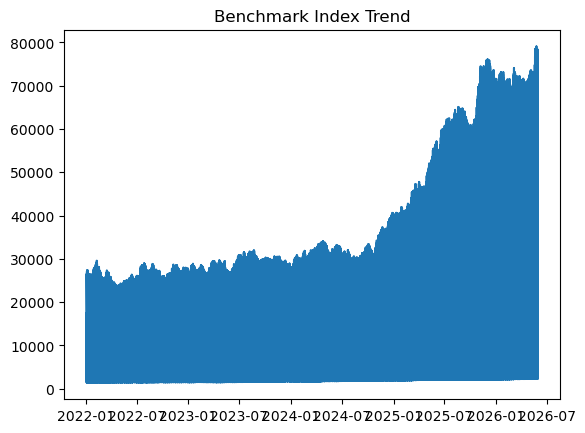

In [ ]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

plt.plot(
    benchmark["date"],
    benchmark["close_value"]
)

plt.title(
    "Benchmark Index Trend"
)
plt.savefig("../reports/benchmark_trend.png", bbox_inches="tight")
plt.show()

Benchmark indices show a positive long-term trend despite short-term fluctuations.

# Key Findings

1. NAV values showed long-term growth across most schemes.
2. SIP investments increased steadily from 2022–2025.
3. Large fund houses dominate industry AUM.
4. Equity-oriented funds delivered strong returns.
5. Folio counts grew consistently over the study period.
6. Investor participation is highest among middle-age groups.
7. Investments are concentrated in major states.
8. Sector allocation is focused on a few key industries.
9. Risk and return metrics exhibit strong relationships.
10. Benchmark indices indicate overall market growth.